# Mice Behavior Analysis — Social & Fear Odor Experiments

**Experimental design.** Groups of 4 mice (*pools*) from 3 autism-associated genetic lines (ash1l, kdm6b, kmt5b) are recorded across two separate olfactory paradigms: a social-odor session and a fear-odor session. Within each session, mice go through three phases: a baseline habituation period (H, 30 min), an odor-exposure period (O, 15 min), and a post-exposure period (P, 15 min). Half the pools carry a heterozygous mutation (*het*) in the gene of their line; the other half are wild-type controls (*wt*).

| Variable | Values | Meaning |
|---|---|---|
| `pool` | rd11, rd13, … | one group of 4 mice recorded together |
| `line` | ash1l / kdm6b / kmt5b | which ASD-associated gene is mutated |
| `genotype` | het / wt | **primary treatment** — mutation carrier vs. control |
| `sex` | male / female | |
| `odor` | social / fear | type of olfactory cue introduced |
| `phase` | H → O → P | habituation → exposure → post-exposure |

**Behaviors scored** (proportion of observation time):

| Label | Name | Description |
|---|---|---|
| `nose-tail` | Nose-to-tail | investigator mouse sniffs tail/anogenital region of another |
| `nose-nose mono` | One-sided nose-to-nose | one mouse approaches another nose-to-nose |
| `nose-nose double` | Mutual nose-to-nose | both mice simultaneously face each other nose-to-nose |
| `nose-nose total` | Total nose-to-nose | weighted sum: `2 × mutual + one-sided` |

**Research questions:**

| # | Question | Section |
|---|---|---|
| RQ1 | Does the odor introduction change social behavior? Does it persist after removal? | §3.1 |
| RQ2 | Does carrying the heterozygous mutation alter social/fear behavior? | §3.2 |
| RQ3 | Do mutant mice respond differently to the odor than wild-type mice? | §3.3 |

In [1]:
import numpy as np
import pandas as pd
import cv2
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 11,
                     'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9})

In [2]:
data_dir = '../../data/mice/v1'

## 1. Data

In [3]:
trial = pd.read_csv(os.path.join(data_dir, 'experiment.csv'))
trial.head(5)

,pool,line,sex,genotype,phase,odor,seed,date,time,annotator,observation_file,annotation_file,valid,observation_id,start_frame,end_frame
0,rd25,ash1l,m,wt,H,S,1,2024-12-02,15:34:27,SD,2024-12-02_15-34-27_BHVScreen_rd25_SocialOdor2...,2024-12-02_15-34-27_BHVScreen_rd25_SocialOdor2...,1,wt_ash1l_m_1_S_H,0,54000
1,rd25,ash1l,m,wt,O,S,1,2024-12-02,16:05:34,SD,2024-12-02_16-05-34_BHVScreen_rd25_SocialOdor2...,2024-12-02_16-05-34_BHVScreen_rd25_SocialOdor2...,1,wt_ash1l_m_1_S_O,0,27000
2,rd25,ash1l,m,wt,P,S,1,2024-12-02,16:24:37,SD,2024-12-02_16-24-37_BHVScreen_rd25_SocialOdor2...,2024-12-02_16-24-37_BHVScreen_rd25_SocialOdor2...,1,wt_ash1l_m_1_S_P,0,27000
3,rd25,ash1l,m,wt,H,F,1,2024-12-02,16:42:33,SD,2024-12-02_16-42-33_BHVScreen_rd25_FearOdor_Ha...,2024-12-02_16-42-33_BHVScreen_rd25_FearOdor_Ha...,1,wt_ash1l_m_1_F_H,0,54000
4,rd25,ash1l,m,wt,O,F,1,2024-12-02,17:16:45,SD,2024-12-02_17-16-45_BHVScreen_rd25_FearOdor_Te...,2024-12-02_17-16-45_BHVScreen_rd25_FearOdor_Te...,1,wt_ash1l_m_1_F_O,0,27000


#### Sample composition

In [4]:
pools = trial.drop_duplicates('pool').copy()
pools['annotated'] = pools['pool'].isin(trial[trial['annotation_file'].notna()]['pool'])

balance = pools.groupby(['line','sex','genotype']).agg(
    total=('pool','count'), annotated=('annotated','sum')
).reset_index()
balance['annotated'] = balance['annotated'].astype(int)

print("Pools recorded (total) and manually annotated, by line x sex x genotype:")
display(balance.pivot_table(index=['line','sex'], columns='genotype',
                             values=['total','annotated'], aggfunc='first'))
print(f"\nAnnotated: {int(pools['annotated'].sum())} / {len(pools)} pools")
print("Important: het pools outnumber wt ~3:1 in the annotated set (17 het vs 5 wt),")
print("which limits the power of genotype comparisons (see section 3.2).")

Pools recorded (total) and manually annotated, by line x sex x genotype:


annotated    total   
genotype        het wt   het wt
line  sex                      
ash1l f           3  1     6  6
      m           3  1     6  6
kdm6b f           3  1     6  6
      m           2  1     6  6
kmt5b f           3  1     6  6
      m           2  1     6  6


Annotated: 22 / 72 pools
Important: het pools outnumber wt ~3:1 in the annotated set (17 het vs 5 wt),
which limits the power of genotype comparisons (see section 3.2).


#### Data quality checks

In [5]:
# Check all video files and annotation files are present
def check_video(row):
    return os.path.exists(f"{data_dir}/observations/full/{row['observation_file']}")
def check_annotation(row):
    if pd.isna(row['annotation_file']) or row['annotation_file'] == '':
        return True
    return os.path.exists(f"{data_dir}/annotations/{row['annotation_file']}")

missing_videos = trial[~trial.apply(check_video, axis=1)]['observation_file'].unique()
ann_rows = trial[trial['annotation_file'].notna() & (trial['annotation_file'] != '')]
missing_labels = ann_rows[~ann_rows.apply(check_annotation, axis=1)]['annotation_file'].unique()
print(f"Missing videos: {len(missing_videos)}")
print(f"Missing annotation files: {len(missing_labels)}")

# Check frame rate and duration
SOURCE_FPS   = 30   # original recording frame rate
STANDARD_FPS = 5    # frame rate after standardisation
def get_video_fps(path):
    return cv2.VideoCapture(path).get(cv2.CAP_PROP_FPS)
def get_video_duration(path):
    cap = cv2.VideoCapture(path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    return 0 if fps == 0 else int(cap.get(cv2.CAP_PROP_FRAME_COUNT) / fps)
fp = lambda x: os.path.join(data_dir, 'observations', 'full', x)
check_fps = (trial['observation_file'].apply(lambda x: get_video_fps(fp(x))) == STANDARD_FPS).all()
expected  = ((trial['end_frame'] - trial['start_frame']) / SOURCE_FPS).astype(int)
actual    = trial['observation_file'].apply(lambda x: get_video_duration(fp(x)))
print(f"All videos at {STANDARD_FPS} fps: {check_fps}")
print(f"All videos correct duration: {(expected == actual).all()}")

Missing videos: 0
Missing annotation files: 0
All videos at 5 fps: True
All videos correct duration: True


## 2. Behavior Scores

Each behavior is expressed as **proportion of observation time** (total scored duration / phase duration). This normalises for the different phase lengths: habituation = 30 min, exposure and post-exposure = 15 min each.

The *mutual nose-to-nose* count is doubled when computing the total, because both mice are simultaneously engaged.

In [6]:
def rel_time(path, action, T):
    b = pd.read_csv(path)
    d = pd.to_numeric(b['Duration (s)'], errors='coerce')
    return d[b['behavior_type'] == action].sum() / T

annotated = trial[trial['annotation_file'].notna() & (trial['annotation_file'] != '')].copy()
annotated['T'] = (annotated['end_frame'] - annotated['start_frame']) / SOURCE_FPS

for code, col in [('nt', 'nose-tail_rt'),
                  ('nn', 'nose-nose_double_rt'),
                  ('np', 'nose-nose_mono_rt')]:
    annotated[col] = annotated.apply(
        lambda x: rel_time(f"{data_dir}/annotations/{x['annotation_file']}", code, x['T']),
        axis=1)
annotated['nose-nose_rt'] = 2 * annotated['nose-nose_double_rt'] + annotated['nose-nose_mono_rt']
annotated = annotated.drop(columns=['T'])
annotated.head(5)

,pool,line,sex,genotype,phase,odor,seed,date,time,annotator,observation_file,annotation_file,valid,observation_id,start_frame,end_frame,nose-tail_rt,nose-nose_double_rt,nose-nose_mono_rt,nose-nose_rt
0,rd25,ash1l,m,wt,H,S,1,2024-12-02,15:34:27,SD,2024-12-02_15-34-27_BHVScreen_rd25_SocialOdor2...,2024-12-02_15-34-27_BHVScreen_rd25_SocialOdor2...,1,wt_ash1l_m_1_S_H,0,54000,0.011167,0.004204,0.016926,0.025334
1,rd25,ash1l,m,wt,O,S,1,2024-12-02,16:05:34,SD,2024-12-02_16-05-34_BHVScreen_rd25_SocialOdor2...,2024-12-02_16-05-34_BHVScreen_rd25_SocialOdor2...,1,wt_ash1l_m_1_S_O,0,27000,0.002037,0.007223,0.009779,0.024226
2,rd25,ash1l,m,wt,P,S,1,2024-12-02,16:24:37,SD,2024-12-02_16-24-37_BHVScreen_rd25_SocialOdor2...,2024-12-02_16-24-37_BHVScreen_rd25_SocialOdor2...,1,wt_ash1l_m_1_S_P,0,27000,0.001888,0.003556,0.018408,0.025519
3,rd25,ash1l,m,wt,H,F,1,2024-12-02,16:42:33,SD,2024-12-02_16-42-33_BHVScreen_rd25_FearOdor_Ha...,2024-12-02_16-42-33_BHVScreen_rd25_FearOdor_Ha...,1,wt_ash1l_m_1_F_H,0,54000,0.000667,0.003055,0.002352,0.008462
4,rd25,ash1l,m,wt,O,F,1,2024-12-02,17:16:45,SD,2024-12-02_17-16-45_BHVScreen_rd25_FearOdor_Te...,2024-12-02_17-16-45_BHVScreen_rd25_FearOdor_Te...,1,wt_ash1l_m_1_F_O,0,27000,0.008556,0.007039,0.003889,0.017967


#### Annotator assignment check

In [7]:
ann_meta = annotated.drop_duplicates('pool')[['pool','line','sex','genotype','annotator']]
print("Number of pools annotated per person x genotype:")
display(pd.crosstab(ann_meta['annotator'], ann_meta['genotype']))
print("\nNumber of pools annotated per person x line:")
display(pd.crosstab(ann_meta['annotator'], ann_meta['line']))
print("\nCaution: annotator SG scored 8 het but only 2 wt pools, creating a partial")
print("confound between annotator identity and genotype. Genotype comparisons should")
print("be interpreted with this in mind.")

Number of pools annotated per person x genotype:


genotype,het,wt
annotator,,
MB,1,2
MF,3,0
MR,1,0
SD,3,2
SG,8,2



Number of pools annotated per person x line:


line,ash1l,kdm6b,kmt5b
annotator,,,
MB,0,2,1
MF,1,2,0
MR,1,0,0
SD,1,1,3
SG,5,2,3



Caution: annotator SG scored 8 het but only 2 wt pools, creating a partial
confound between annotator identity and genotype. Genotype comparisons should
be interpreted with this in mind.


## 3. Statistical Analysis

**Approach.** All comparisons are two-tailed. Effect sizes are reported as Cohen's *d* (small ≈ 0.2, medium ≈ 0.5, large ≈ 0.8). Because we test 4 behaviors × 2 odors × multiple conditions, we correct for multiple comparisons using the Benjamini-Hochberg false discovery rate (FDR); the adjusted values are reported as *q*-values alongside raw *p*-values.

In [8]:
BEHAVIORS = ['nose-tail_rt', 'nose-nose_mono_rt', 'nose-nose_double_rt', 'nose-nose_rt']
LABELS    = ['Nose-to-tail', 'Nose-to-nose\n(one-sided)', 'Nose-to-nose\n(mutual)', 'Nose-to-nose\n(total)']
TITLES    = ['Nose-to-tail', 'Nose-to-nose (one-sided)', 'Nose-to-nose (mutual)', 'Nose-to-nose (total)']
PHASE_FULL = {'H': 'Habituation', 'O': 'Exposure', 'P': 'Post-exposure'}
ODOR_FULL  = {'S': 'Social odor', 'F': 'Fear odor'}
GENO_COLOR = {'het': '#D62728', 'wt': '#1F77B4'}   # red = mutant, blue = wild-type

def cohens_d(x, y):
    n1, n2 = len(x), len(y)
    s = np.sqrt(((n1-1)*x.var(ddof=1) + (n2-1)*y.var(ddof=1)) / (n1+n2-2))
    return (x.mean() - y.mean()) / s if s > 0 else 0.0

def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals); order = np.argsort(pvals)
    q = np.minimum(1, n * pvals[order] / (np.arange(n) + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty(n); out[order] = q
    return out

def stars(p):
    return '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

### RQ1 — Effect of odor introduction on behavior

**Rationale.** The odor introduction at phase O is a controlled experimental intervention, so comparing O to the habituation baseline H is a genuine causal contrast. We exploit the repeated-measures structure: for each pool we compute the *within-pool change* (Exposure − Habituation) and ask whether the mean change across pools differs from zero. This uses each pool as its own control, removing any between-pool differences in baseline activity.

A one-sample *t*-test on these within-pool differences is used. Post-removal persistence is tested as the O → P change.

In [9]:
def paired_ate(df, p1, p0, odor, behavior):
    wide  = df[df['odor']==odor].pivot_table(index='pool', columns='phase', values=behavior)
    if p0 not in wide.columns or p1 not in wide.columns: return None
    delta = (wide[p1] - wide[p0]).dropna()
    if len(delta) < 2: return None
    t, p = stats.ttest_1samp(delta, 0)
    d = delta.mean() / delta.std(ddof=1) if delta.std(ddof=1) > 0 else np.nan
    return {'Odor': ODOR_FULL[odor], 'Transition': f'{PHASE_FULL[p0]} to {PHASE_FULL[p1]}',
            'Behavior': TITLES[BEHAVIORS.index(behavior)],
            'Mean change': delta.mean(), 'SE': delta.sem(),
            "Cohen's d": d, 't': t, 'p': p, 'n pools': len(delta)}

rows = []
for odor in ['S', 'F']:
    for p0, p1 in [('H', 'O'), ('O', 'P')]:
        for beh in BEHAVIORS:
            r = paired_ate(annotated, p1, p0, odor, beh)
            if r: rows.append(r)

phase_ate = pd.DataFrame(rows)
phase_ate['q (FDR)'] = fdr_bh(phase_ate['p'])
phase_ate['sig']     = phase_ate['q (FDR)'].apply(stars)
display(phase_ate[['Odor','Transition','Behavior','Mean change','SE',"Cohen's d",'p','q (FDR)','sig','n pools']].round(4))

,Odor,Transition,Behavior,Mean change,SE,Cohen's d,p,q (FDR),sig,n pools
0,Social odor,Habituation to Exposure,Nose-to-tail,-0.0027,0.0023,-0.2527,0.2604,0.3472,,21
1,Social odor,Habituation to Exposure,Nose-to-nose (one-sided),-0.0055,0.0018,-0.6707,0.0060,0.0320,*,21
2,Social odor,Habituation to Exposure,Nose-to-nose (mutual),-0.0017,0.0034,-0.1052,0.6349,0.7256,,21
3,Social odor,Habituation to Exposure,Nose-to-nose (total),-0.0088,0.0067,-0.2865,0.2041,0.3325,,21
4,Social odor,Exposure to Post-exposure,Nose-to-tail,0.0001,0.0028,0.0067,0.9758,0.9758,,21
5,Social odor,Exposure to Post-exposure,Nose-to-nose (one-sided),0.0028,0.0021,0.2838,0.2082,0.3325,,21
6,Social odor,Exposure to Post-exposure,Nose-to-nose (mutual),-0.0020,0.0016,-0.2710,0.2286,0.3325,,21
7,Social odor,Exposure to Post-exposure,Nose-to-nose (total),-0.0013,0.0044,-0.0657,0.7663,0.8174,,21
8,Fear odor,Habituation to Exposure,Nose-to-tail,0.0090,0.0038,0.5009,0.0287,0.0918,,22
9,Fear odor,Habituation to Exposure,Nose-to-nose (one-sided),0.0066,0.0028,0.5039,0.0278,0.0918,,22


**Results — RQ1.** Fear odor reliably increases close social investigation during exposure:
- **Mutual nose-to-nose** (H→O): mean change = +0.005, *d* = 0.74, *q* = 0.022 ✓
- **Total nose-to-nose** (H→O): mean change = +0.017, *d* = 0.72, *q* = 0.022 ✓
- One-sided nose-to-nose and nose-to-tail show consistent positive trends (*d* ≈ 0.50) but do not survive multiple-comparison correction.

Social odor shows the opposite: a modest *decrease* in one-sided nose-to-nose during exposure (H→O: *d* = −0.67, *q* = 0.032 ✓), suggesting less directed sniffing when a familiar conspecific odor is present.

No O→P change is significant after FDR correction: **the behavioral shifts during odor exposure do not persist** once the odor is removed.

*Conclusion:* the fear-odor manipulation successfully drives a detectable increase in olfactory social investigation, validating the experimental design.

### RQ2 — Effect of the mutation on behavior

**Rationale.** Genotype (het vs. wt) is determined by Mendelian inheritance and can be treated as a natural randomized assignment. Wild-type pools from all three lines are pooled as a common control group, because wt mice share the same unperturbed genetic background at the locus of interest regardless of line. This pooling is necessary given that only ~1 wt pool per sex/line combination has been annotated so far. A Welch two-sample *t*-test is used, stratified by sex.

**Power note.** With 5–6 wt pools vs. 15–17 het pools, the study has ≈80% power to detect *d* ≈ 1.1. The medium effects expected from ASD mouse models (*d* ≈ 0.5–0.8) require ≈10–26 wt pools for reliable detection.

In [10]:
def genotype_ate(df, odor, phase, behavior, stratify_by='sex'):
    sub  = df[(df['odor']==odor) & (df['phase']==phase)]
    rows = []
    for label, g in [('All', sub)] + [(v.capitalize(), sub[sub[stratify_by]==v])
                                       for v in sorted(sub[stratify_by].unique())]:
        het = g[g['genotype']=='het'][behavior].dropna()
        wt  = g[g['genotype']=='wt'][behavior].dropna()
        if len(het) < 2 or len(wt) < 2: continue
        t, p = stats.ttest_ind(het, wt, equal_var=False)
        rows.append({stratify_by.capitalize(): label,
                     'Odor': ODOR_FULL[odor], 'Phase': PHASE_FULL[phase],
                     'Behavior': TITLES[BEHAVIORS.index(behavior)],
                     'het mean': het.mean(), 'wt mean': wt.mean(),
                     'Mean diff (het-wt)': het.mean()-wt.mean(),
                     'SE': np.sqrt(het.var(ddof=1)/len(het)+wt.var(ddof=1)/len(wt)),
                     "Cohen's d": cohens_d(het, wt),
                     'p': p, 'n het': len(het), 'n wt': len(wt)})
    return pd.DataFrame(rows)

geno_rows = []
for odor in ['S', 'F']:
    for phase in ['H', 'O', 'P']:
        for beh in BEHAVIORS:
            geno_rows.append(genotype_ate(annotated, odor, phase, beh))

geno_ate = pd.concat(geno_rows, ignore_index=True)
geno_ate['q (FDR)'] = fdr_bh(geno_ate['p'])
geno_ate['sig']     = geno_ate['q (FDR)'].apply(stars)
display(geno_ate[['Odor','Phase','Behavior','Sex','het mean','wt mean',
                   'Mean diff (het-wt)',"Cohen's d",'p','q (FDR)','sig','n het','n wt']].round(4))

,Odor,Phase,Behavior,Sex,het mean,wt mean,Mean diff (het-wt),Cohen's d,p,q (FDR),sig,n het,n wt
0,Social odor,Habituation,Nose-to-tail,All,0.0150,0.0102,0.0048,0.3662,0.2811,0.6747,,15,6
1,Social odor,Habituation,Nose-to-tail,F,0.0076,0.0094,-0.0018,-0.2220,0.7402,0.8532,,8,3
2,Social odor,Habituation,Nose-to-tail,M,0.0234,0.0111,0.0123,0.8467,0.1009,0.6378,,7,3
3,Social odor,Habituation,Nose-to-nose (one-sided),All,0.0157,0.0178,-0.0020,-0.2476,0.5053,0.7155,,15,6
4,Social odor,Habituation,Nose-to-nose (one-sided),F,0.0157,0.0166,-0.0009,-0.0908,0.8486,0.8955,,8,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Fear odor,Post-exposure,Nose-to-nose (mutual),F,0.0078,0.0068,0.0010,0.1847,0.6983,0.8532,,9,3
68,Fear odor,Post-exposure,Nose-to-nose (mutual),M,0.0065,0.0051,0.0014,0.2748,0.6216,0.8138,,7,3
69,Fear odor,Post-exposure,Nose-to-nose (total),All,0.0257,0.0200,0.0057,0.3095,0.3236,0.6887,,16,6
70,Fear odor,Post-exposure,Nose-to-nose (total),F,0.0312,0.0200,0.0112,0.5022,0.2215,0.6378,,9,3


**Results — RQ2.** No genotype comparison survives FDR correction (*q* > 0.40 throughout). However, this reflects **low statistical power** rather than an absence of effect:
- Mutant (het) mice show consistently *higher* social investigation across all conditions: baseline nose-to-nose total = 0.031 (het) vs. 0.018 (wt)
- The strongest raw effects appear for fear odor at habituation: one-sided nose-to-nose (*d* = 0.79, *p* = 0.018) and total nose-to-nose (*d* = 0.67, *p* = 0.062)
- Effect sizes of *d* = 0.4–0.8 are biologically meaningful for a heterozygous model, but reliably detecting them requires 10–26 annotated wt pools

*Conclusion:* the direction of effects is consistent with increased social investigation in mutant mice, but the dataset is underpowered. Completing the annotation of wt pools is the key next step.

### RQ3 — Genotype × odor interaction

**Rationale.** Even if mutant mice have a different baseline, they might still respond similarly to the odor. Here we ask whether the *change* in behavior from habituation to exposure (H→O delta) differs between het and wt pools. A significant difference would indicate that the mutation alters the animal's sensitivity or reactivity to the olfactory cue.

In [11]:
def geno_x_phase(df, p1, p0, odor, behavior):
    wide = df[df['odor']==odor].pivot_table(
        index=['pool','genotype'], columns='phase', values=behavior).reset_index()
    if p0 not in wide.columns or p1 not in wide.columns: return None
    wide['delta'] = wide[p1] - wide[p0]
    wide = wide.dropna(subset=['delta'])
    het, wt = wide[wide['genotype']=='het']['delta'], wide[wide['genotype']=='wt']['delta']
    if len(het) < 2 or len(wt) < 2: return None
    t, p = stats.ttest_ind(het, wt, equal_var=False)
    return {'Odor': ODOR_FULL[odor],
            'Transition': f'{PHASE_FULL[p0]} to {PHASE_FULL[p1]}',
            'Behavior': TITLES[BEHAVIORS.index(behavior)],
            'het delta': het.mean(), 'wt delta': wt.mean(),
            'Difference (het-wt)': het.mean()-wt.mean(),
            "Cohen's d": cohens_d(het, wt),
            'SE': np.sqrt(het.var(ddof=1)/len(het)+wt.var(ddof=1)/len(wt)),
            'p': p, 'n het': len(het), 'n wt': len(wt)}

inter_rows = []
for odor in ['S', 'F']:
    for p0, p1 in [('H', 'O'), ('O', 'P')]:
        for beh in BEHAVIORS:
            r = geno_x_phase(annotated, p1, p0, odor, beh)
            if r: inter_rows.append(r)

interaction = pd.DataFrame(inter_rows)
interaction['q (FDR)'] = fdr_bh(interaction['p'])
interaction['sig']     = interaction['q (FDR)'].apply(stars)
display(interaction[['Odor','Transition','Behavior','het delta','wt delta',
                      'Difference (het-wt)',"Cohen's d",'p','q (FDR)','sig']].round(4))

,Odor,Transition,Behavior,het delta,wt delta,Difference (het-wt),Cohen's d,p,q (FDR),sig
0,Social odor,Habituation to Exposure,Nose-to-tail,-0.0023,-0.0036,0.0013,0.1165,0.8283,0.9612,
1,Social odor,Habituation to Exposure,Nose-to-nose (one-sided),-0.0042,-0.0088,0.0047,0.5753,0.2618,0.7531,
2,Social odor,Habituation to Exposure,Nose-to-nose (mutual),-0.0038,0.0037,-0.0075,-0.4762,0.1460,0.7531,
3,Social odor,Habituation to Exposure,Nose-to-nose (total),-0.0118,-0.0014,-0.0104,-0.3316,0.3275,0.7531,
4,Social odor,Exposure to Post-exposure,Nose-to-tail,-0.0020,0.0052,-0.0071,-0.5703,0.3295,0.7531,
5,Social odor,Exposure to Post-exposure,Nose-to-nose (one-sided),-0.0004,0.0106,-0.0110,-1.2822,0.0176,0.2816,
6,Social odor,Exposure to Post-exposure,Nose-to-nose (mutual),-0.0022,-0.0016,-0.0006,-0.0838,0.8313,0.9612,
7,Social odor,Exposure to Post-exposure,Nose-to-nose (total),-0.0048,0.0074,-0.0123,-0.6211,0.1347,0.7531,
8,Fear odor,Habituation to Exposure,Nose-to-tail,0.0088,0.0094,-0.0006,-0.0339,0.9303,0.9809,
9,Fear odor,Habituation to Exposure,Nose-to-nose (one-sided),0.0070,0.0056,0.0014,0.1013,0.7496,0.9612,


**Results — RQ3.** No interaction survives FDR correction. For fear odor, mutant and wild-type mice show virtually identical changes during odor exposure (e.g., nose-to-tail H→O: het Δ = +0.009, wt Δ = +0.009, *d* = −0.03). The social-odor post-exposure comparison shows a trend for one-sided nose-to-nose (*d* = −1.28, *p* = 0.018, *q* = 0.28), but this is driven by the small wt group (n = 5) and does not replicate across behaviors.

*Conclusion:* mutant and wild-type mice respond with similar magnitude to the odor introduction. The mutation does not appear to alter odor reactivity with current sample sizes.

### Are the behavior measures independent?

Before interpreting multiple behavior outcomes, it is important to check whether they reflect the same underlying construct. High correlation (Spearman ρ > 0.8) would indicate redundancy; low correlation (ρ < 0.3) would suggest truly independent processes.

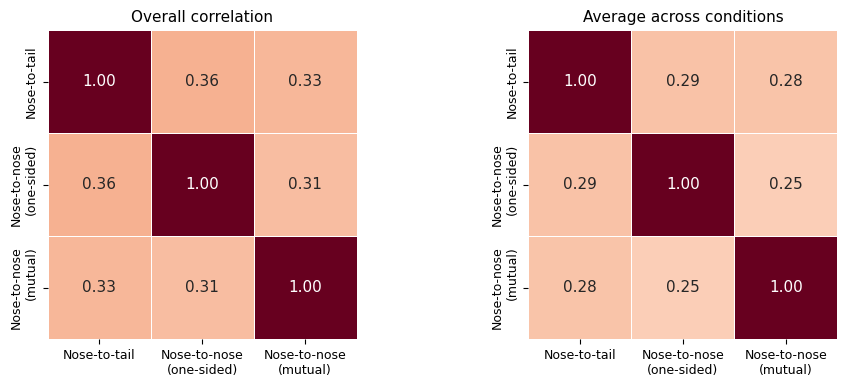

In [12]:
BEH3  = ['nose-tail_rt', 'nose-nose_mono_rt', 'nose-nose_double_rt']
SHORT = ['Nose-to-tail', 'Nose-to-nose\n(one-sided)', 'Nose-to-nose\n(mutual)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
kw = dict(annot=True, fmt='.2f', vmin=-1, vmax=1, cmap='RdBu_r',
          square=True, linewidths=0.5, cbar=False)
rename = dict(zip(BEH3, SHORT))

corr_all  = annotated[BEH3].corr(method='spearman').rename(index=rename, columns=rename)
corr_mean = (annotated.groupby(['odor','phase'])[BEH3].corr(method='spearman')
             .groupby(level=2).mean().loc[BEH3, BEH3].rename(index=rename, columns=rename))

sns.heatmap(corr_all,  ax=axes[0], **kw); axes[0].set_title('Overall correlation')
sns.heatmap(corr_mean, ax=axes[1], **kw); axes[1].set_title('Average across conditions')
plt.tight_layout()
plt.savefig('results/behavior_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Result.** All pairwise Spearman correlations are moderate (ρ ≈ 0.31–0.36), indicating that nose-to-tail and nose-to-nose behaviors capture **related but distinct** aspects of social investigation — none approaches redundancy. The nose-to-nose total is a derived composite of the other two measures and is included as a summary statistic only.

## 4. Visualizations

### 4.1 Behavior trajectories across phases

Each thin line follows one pool across the three phases; the thicker line with error bars shows the group mean ± SEM. Red = mutant (het), blue = wild-type (wt). Dashed vertical lines mark phase boundaries.

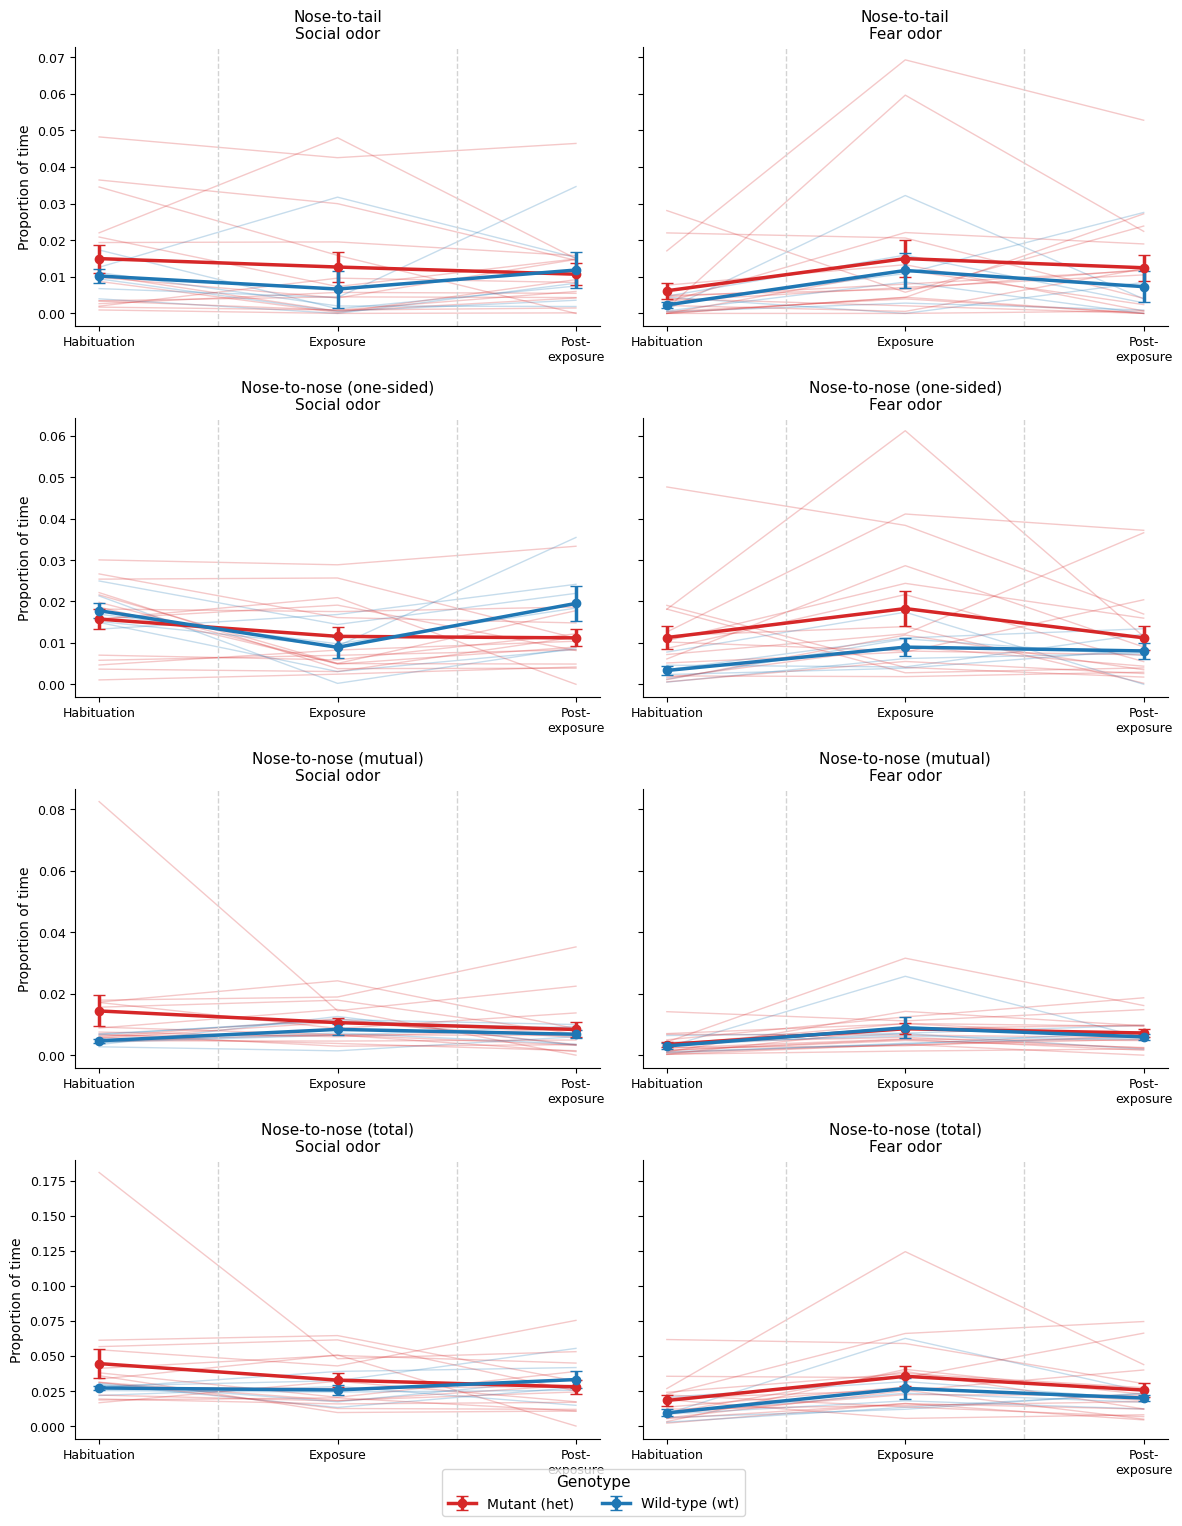

In [13]:
PHASE_ORDER = ['H', 'O', 'P']
PHASE_TICK  = ['Habituation', 'Exposure', 'Post-\nexposure']

fig, axes = plt.subplots(len(BEHAVIORS), 2, figsize=(12, 15), sharey='row')

for i, (beh, title) in enumerate(zip(BEHAVIORS, TITLES)):
    for j, (odor, olabel) in enumerate([('S', 'Social odor'), ('F', 'Fear odor')]):
        ax   = axes[i, j]
        data = annotated[annotated['odor'] == odor]

        # individual pool lines (thin, transparent)
        for _, pool_data in data.groupby('pool'):
            pd_re = pool_data.set_index('phase').reindex(PHASE_ORDER)
            if pd_re[beh].isna().any(): continue
            geno = pd_re['genotype'].dropna().iloc[0]
            ax.plot(range(3), pd_re[beh].values,
                    color=GENO_COLOR[geno], alpha=0.25, linewidth=1)

        # group means ± SEM (thick)
        for geno, color in GENO_COLOR.items():
            grp   = data[data['genotype'] == geno]
            means = [grp[grp['phase']==p][beh].mean() for p in PHASE_ORDER]
            sems  = [grp[grp['phase']==p][beh].sem()  for p in PHASE_ORDER]
            lbl   = 'Mutant (het)' if geno == 'het' else 'Wild-type (wt)'
            ax.errorbar(range(3), means, yerr=sems, color=color,
                        linewidth=2.5, marker='o', markersize=6, capsize=4, label=lbl)

        ax.set_xticks(range(3))
        ax.set_xticklabels(PHASE_TICK)
        ax.set_title(title + '\n' + olabel)
        ax.set_ylabel('Proportion of time' if j == 0 else '')
        for xv in [0.5, 1.5]:
            ax.axvline(xv, color='lightgray', linestyle='--', linewidth=1)
        sns.despine(ax=ax)

handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels_leg, title='Genotype', loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=True, fontsize=10)
plt.tight_layout()
fig.savefig('results/trajectories.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Variation across genetic lines

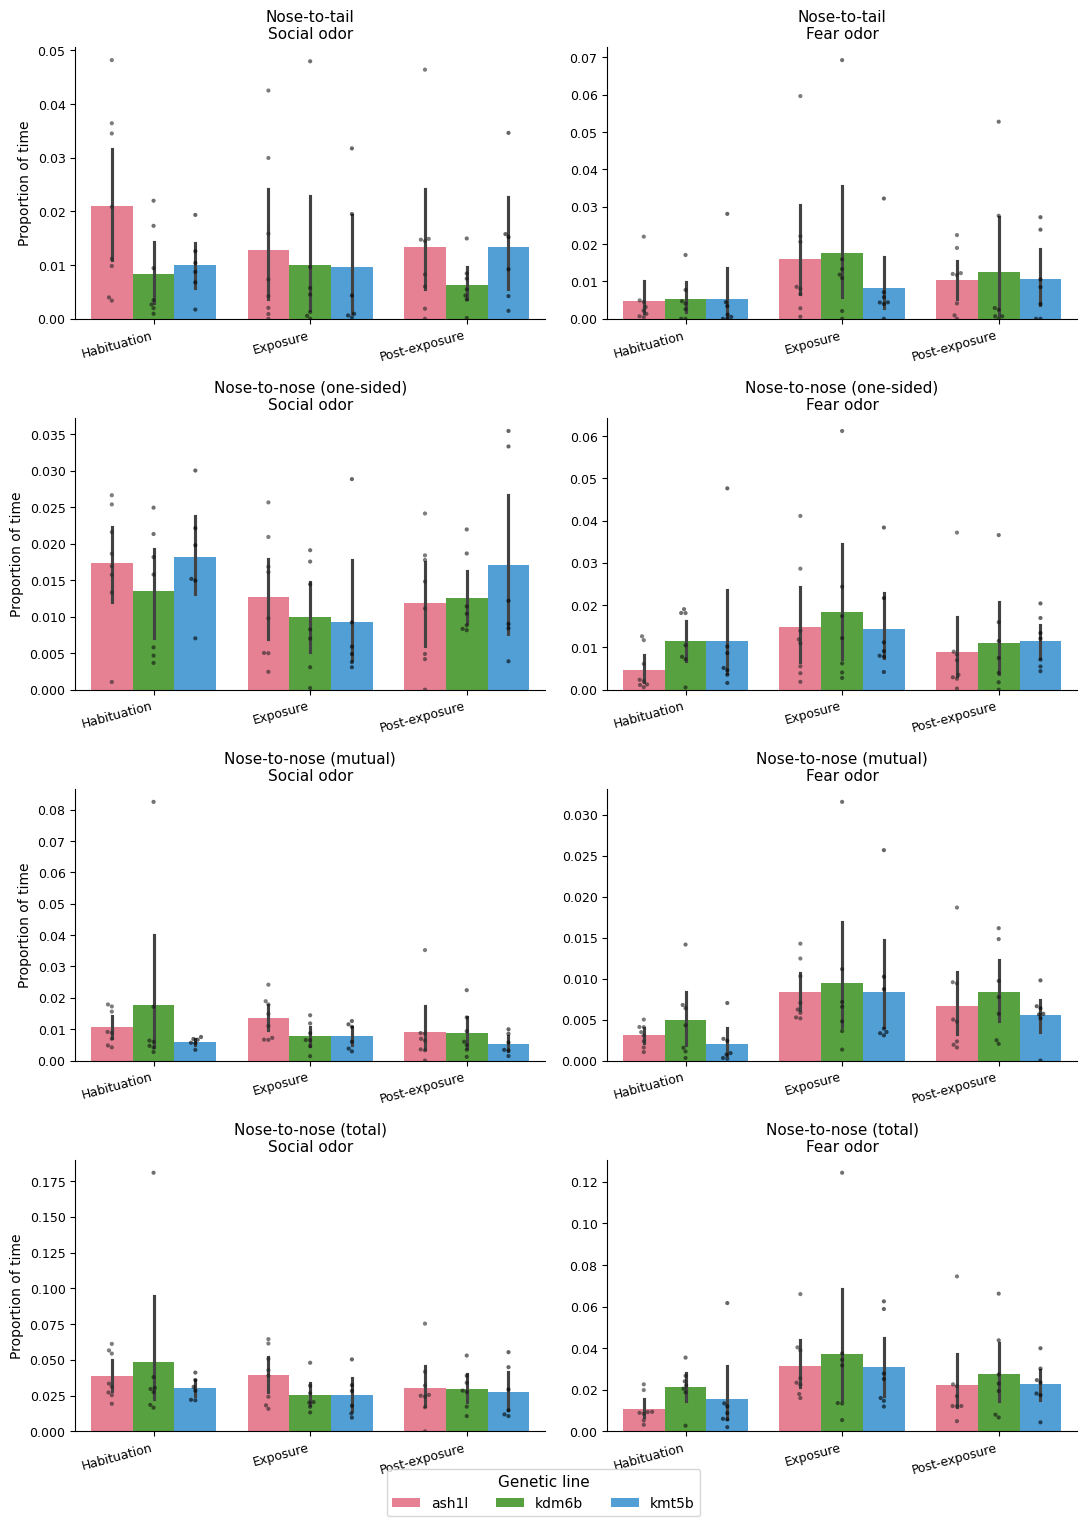

In [14]:
unique_lines = sorted(annotated['line'].unique())
line_palette = dict(zip(unique_lines, sns.color_palette('husl', len(unique_lines))))

fig, axes = plt.subplots(len(BEHAVIORS), 2, figsize=(11, 15))
for i, (beh, title) in enumerate(zip(BEHAVIORS, TITLES)):
    for j, (odor, olabel) in enumerate([('S', 'Social odor'), ('F', 'Fear odor')]):
        ax   = axes[i, j]
        data = annotated[annotated['odor'] == odor]
        sns.barplot(x='phase', y=beh, hue='line', data=data, ax=ax, palette=line_palette)
        sns.swarmplot(x='phase', y=beh, hue='line', data=data,
                      dodge=True, size=3, color='black', alpha=0.6, ax=ax, legend=False)
        ax.set_xticklabels([PHASE_FULL[p] for p in ['H','O','P']], rotation=15, ha='right')
        ax.set_title(title + '\n' + olabel)
        ax.set_ylabel('Proportion of time' if j == 0 else '')
        ax.set_xlabel('')
        ax.legend([], [], frameon=False)
        sns.despine(ax=ax)

handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, unique_lines, title='Genetic line', loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, fontsize=10)
plt.tight_layout()
fig.savefig('results/pa_line.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Sex differences

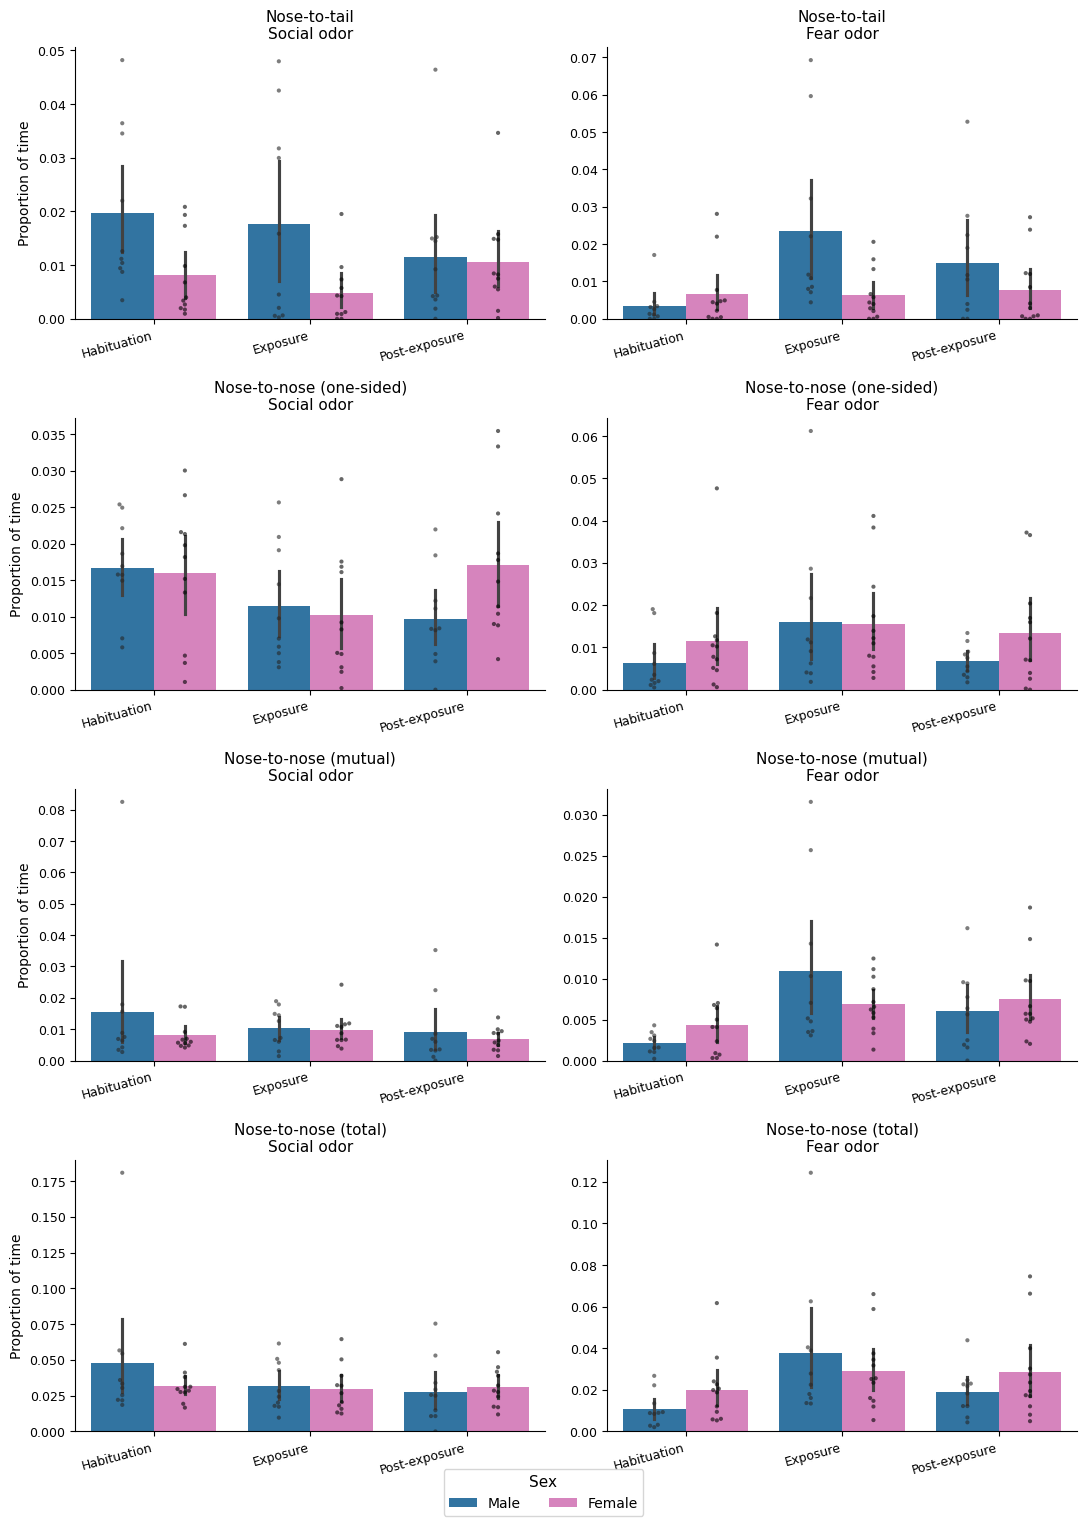

In [15]:
sex_palette = {'f': '#E377C2', 'm': '#1F77B4'}
sex_labels  = {'f': 'Female', 'm': 'Male'}

fig, axes = plt.subplots(len(BEHAVIORS), 2, figsize=(11, 15))
for i, (beh, title) in enumerate(zip(BEHAVIORS, TITLES)):
    for j, (odor, olabel) in enumerate([('S', 'Social odor'), ('F', 'Fear odor')]):
        ax   = axes[i, j]
        data = annotated[annotated['odor'] == odor]
        sns.barplot(x='phase', y=beh, hue='sex', data=data, ax=ax, palette=sex_palette)
        sns.swarmplot(x='phase', y=beh, hue='sex', data=data,
                      dodge=True, size=3, color='black', alpha=0.6, ax=ax, legend=False)
        ax.set_xticklabels([PHASE_FULL[p] for p in ['H','O','P']], rotation=15, ha='right')
        ax.set_title(title + '\n' + olabel)
        ax.set_ylabel('Proportion of time' if j == 0 else '')
        ax.set_xlabel('')
        ax.legend([], [], frameon=False)
        sns.despine(ax=ax)

handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, [sex_labels[l] for l in labels_leg], title='Sex',
           loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=True, fontsize=10)
plt.tight_layout()
fig.savefig('results/pa_sex.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.4 Mutation effect size across conditions (RQ2)

Each point shows the mean difference (mutant − wild-type) ± SEM for one condition (phase × odor). The dashed vertical line marks zero (no effect). Colors indicate odor type; stars indicate FDR-corrected significance. All points currently fall within ±2 SE of zero, consistent with the underpowering noted in §3.2.

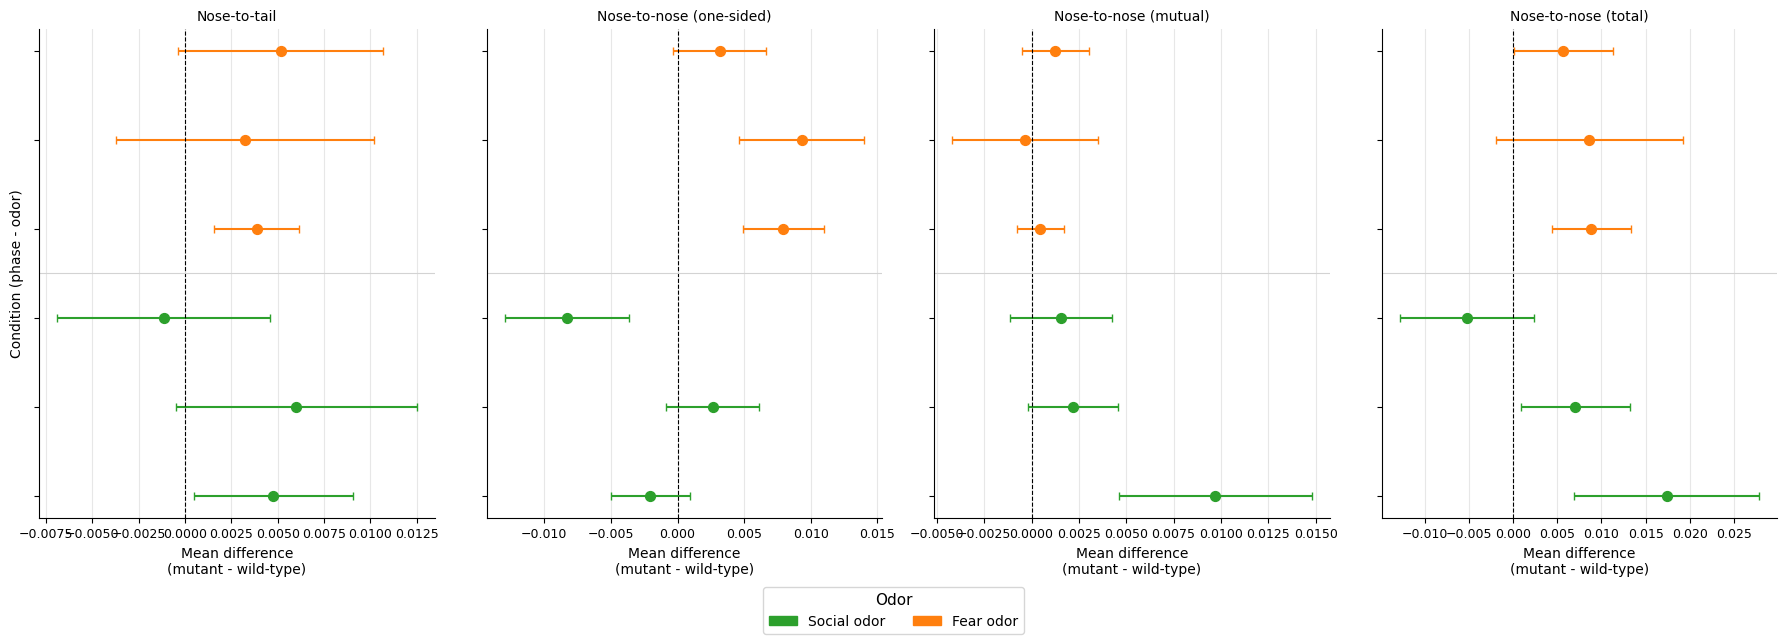

In [16]:
plot_data = geno_ate[geno_ate['Sex'] == 'All'].copy().reset_index(drop=True)
COND_ORDER = [f'{PHASE_FULL[p]} - {ODOR_FULL[o]}' for o in ['S','F'] for p in ['H','O','P']]
plot_data['condition'] = plot_data['Phase'] + ' - ' + plot_data['Odor']
plot_data['y'] = plot_data['condition'].map({c: i for i, c in enumerate(COND_ORDER)})
ODOR_COLOR = {'Social odor': '#2CA02C', 'Fear odor': '#FF7F0E'}

fig, axes = plt.subplots(1, len(BEHAVIORS), figsize=(18, 6), sharey=True)

for ax, beh, title in zip(axes, BEHAVIORS, TITLES):
    sub = plot_data[plot_data['Behavior'] == title].sort_values('y').reset_index(drop=True)

    for _, row in sub.iterrows():
        color = ODOR_COLOR[row['Odor']]
        ax.errorbar(row['Mean diff (het-wt)'], row['y'], xerr=row['SE'],
                    fmt='none', ecolor=color, elinewidth=1.5, capsize=3)
        ax.scatter(row['Mean diff (het-wt)'], row['y'], color=color, zorder=3, s=50)
        if row['sig']:
            ax.text(row['Mean diff (het-wt)'] + row['SE'] + 0.0005, row['y'],
                    row['sig'], va='center', fontsize=9)

    ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_yticks(range(len(COND_ORDER)))
    if ax is axes[0]:
        ax.set_yticklabels(COND_ORDER, fontsize=8)
        ax.set_ylabel('Condition (phase - odor)')
    else:
        ax.set_yticklabels([])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Mean difference\n(mutant - wild-type)')
    ax.invert_yaxis()
    ax.axhline(2.5, color='lightgray', linewidth=0.8)
    ax.grid(axis='x', alpha=0.3)
    sns.despine(ax=ax)

patches = [mpatches.Patch(color=ODOR_COLOR[l], label=l)
           for l in ['Social odor', 'Fear odor']]
fig.legend(handles=patches, title='Odor', loc='lower center',
           bbox_to_anchor=(0.5, -0.08), ncol=2, frameon=True, fontsize=10)
plt.tight_layout()
fig.savefig('results/genotype_ate.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.5 Odor-evoked change by genotype (RQ3)

Each point is one pool's within-pool change from habituation to exposure (H→O). The diamond marks the group mean. Overlap between red (mutant) and blue (wild-type) distributions indicates similar odor responses.

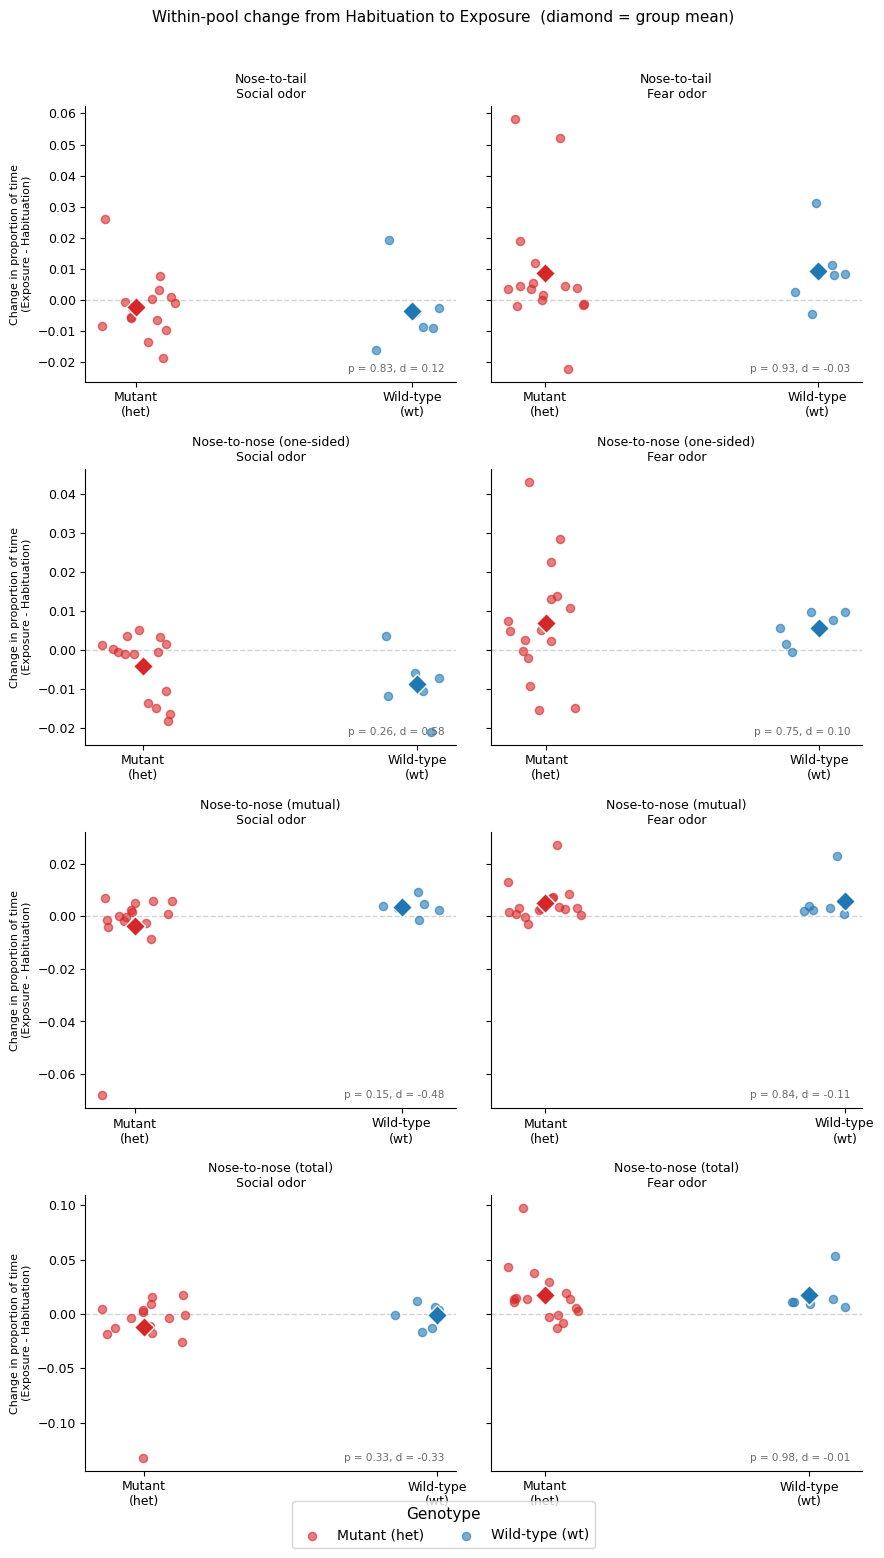

In [17]:
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(BEHAVIORS), 2, figsize=(9, 15), sharey='row')

for i, (beh, title) in enumerate(zip(BEHAVIORS, TITLES)):
    for j, (odor, olabel) in enumerate([('S', 'Social odor'), ('F', 'Fear odor')]):
        ax = axes[i, j]
        wide = annotated[annotated['odor']==odor].pivot_table(
            index=['pool','genotype'], columns='phase', values=beh).reset_index()
        wide['delta'] = wide['O'] - wide['H']
        wide = wide.dropna(subset=['delta'])

        for k, (geno, color) in enumerate(GENO_COLOR.items()):
            d = wide[wide['genotype']==geno]['delta']
            jitter = (rng.random(len(d)) - 0.5) * 0.3
            lbl = 'Mutant (het)' if geno == 'het' else 'Wild-type (wt)'
            ax.scatter(np.full(len(d), k) + jitter, d,
                       color=color, alpha=0.6, s=35, zorder=3, label=lbl)
            ax.plot(k, d.mean(), marker='D', color=color,
                    markersize=10, zorder=5, markeredgecolor='white', markeredgewidth=1)

        ax.axhline(0, color='lightgray', linestyle='--', linewidth=1)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Mutant\n(het)', 'Wild-type\n(wt)'], fontsize=9)
        ax.set_title(title + '\n' + olabel, fontsize=9)
        ax.set_ylabel('Change in proportion of time\n(Exposure - Habituation)' if j == 0 else '', fontsize=8)

        r = geno_x_phase(annotated, 'O', 'H', odor, beh)
        if r:
            d_val = r["Cohen's d"]
            ax.text(0.97, 0.03, f"p = {r['p']:.2f}, d = {d_val:.2f}",
                    transform=ax.transAxes, ha='right', va='bottom',
                    fontsize=7.5, color='dimgray')
        sns.despine(ax=ax)

handles, labels_leg = axes[0, 0].get_legend_handles_labels()
fig.legend(handles[:2], labels_leg[:2], title='Genotype', loc='lower center',
           bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=True, fontsize=10)
plt.suptitle('Within-pool change from Habituation to Exposure  (diamond = group mean)',
             y=1.01, fontsize=11)
plt.tight_layout()
fig.savefig('results/delta_distributions.png', dpi=300, bbox_inches='tight')
plt.show()